# Multi-class One-vs-Rest (OvR) ROC Curve Analizi

Bu çalışmada, siroz hastalarının durum tahmini veri seti üzerinde eğitilen final model adayımızın sınıfları ayrıştırma gücünü ölçmek amacıyla **One-vs-Rest (OvR) ROC Curve** ve **AUC (Area Under Curve)** analizi gerçekleştirilmiştir.

### Model Tanımı:
- **Model:** `LGBMClassifier`
- **class_weight:** `'balanced'`
- **Parametreler:** Hiperparametre optimizasyonu sonucu elde edilen en iyi parametreler.

### Analiz Detayları:
- Her sınıf için ayrı ayrı (C vs Rest, CL vs Rest, D vs Rest) ROC Curve ve AUC hesaplanmıştır.
- Genel ayrıştırma gücünü görmek için **Macro Average AUC** skoru hesaplanmıştır.


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score
from lightgbm import LGBMClassifier

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


In [2]:
# Veri Yükleme
df = pd.read_csv('../data/processed_train.csv')
X = df.drop(columns=['Status'])
y = df['Status']

# Train/Test Split (%20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Eğitim Seti: {X_train.shape}, Test Seti: {X_test.shape}")

Eğitim Seti: (6324, 30), Test Seti: (1581, 30)


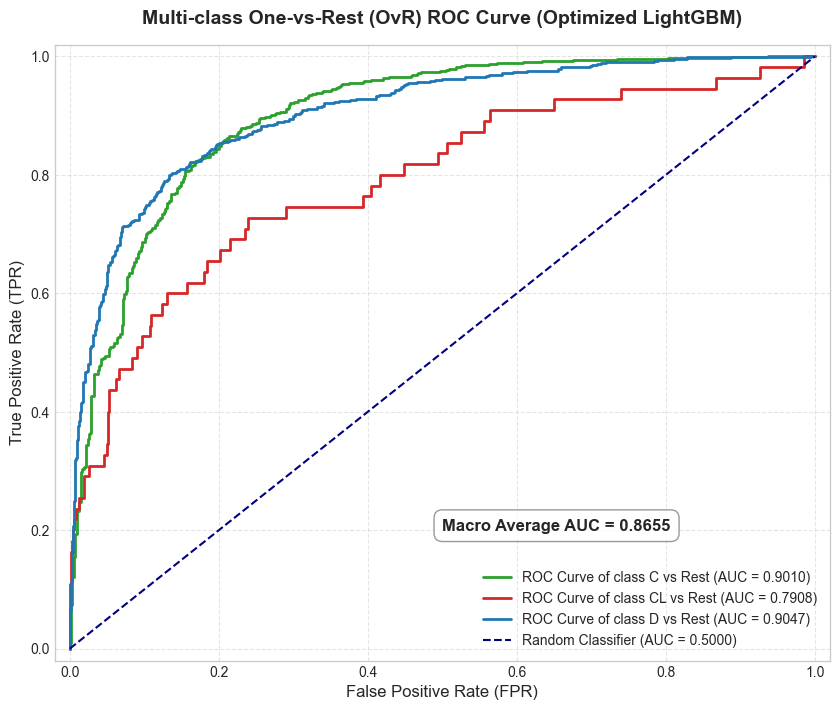

,Class,AUC
0,C,0.900955
1,CL,0.790754
2,D,0.904668
3,Macro Average,0.865459


In [3]:
# Model Tanımı
best_params = {
    'subsample_freq': 1,
    'subsample': 1.0,
    'reg_lambda': 0.1,
    'reg_alpha': 5.0,
    'num_leaves': 127,
    'n_estimators': 500,
    'min_child_samples': 30,
    'max_depth': 5,
    'learning_rate': 0.05,
    'colsample_bytree': 0.9,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1
}

model = LGBMClassifier(**best_params)
model.fit(X_train, y_train)

# Olasılık Tahminleri (predict_proba)
y_prob = model.predict_proba(X_test)

# Sınıflar
classes = {0: 'C', 1: 'CL', 2: 'D'}
roc_data = {}
auc_scores = {}

# Her sınıf için ROC ve AUC hesaplama (OvR)
for class_id, class_name in classes.items():
    y_test_bin = (y_test == class_id).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob[:, class_id])
    roc_auc = auc(fpr, tpr)
    
    roc_data[class_name] = (fpr, tpr, roc_auc)
    auc_scores[class_name] = roc_auc

# Macro Average AUC
macro_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
auc_scores['Macro Average'] = macro_auc

# Sonuçları Kaydetme
results_df = pd.DataFrame(list(auc_scores.items()), columns=['Class', 'AUC'])
os.makedirs('../outputs', exist_ok=True)
results_df.to_csv('../outputs/roc_results.csv', index=False)

# Grafik Çizimi
plt.figure(figsize=(10, 8))

colors = {'C': '#2ca02c', 'CL': '#d62728', 'D': '#1f77b4'}
for class_name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(
        fpr, tpr, 
        color=colors[class_name], 
        lw=2, 
        label=f'ROC Curve of class {class_name} vs Rest (AUC = {roc_auc:.4f})'
    )

plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.5000)')

# Macro Average AUC Metni
plt.text(
    0.5, 0.2, 
    f'Macro Average AUC = {macro_auc:.4f}', 
    fontsize=12, 
    fontweight='bold', 
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5')
)

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Multi-class One-vs-Rest (OvR) ROC Curve (Optimized LightGBM)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('../outputs/roc_curve_ovr.png', dpi=300, bbox_inches='tight')
plt.show()

# Tabloyu göster
results_df

## ROC ve AUC Bulgularının Değerlendirilmesi

Elde edilen grafik ve AUC skorları doğrultusunda şu analizler yapılmıştır:

### 1. Her Sınıfın AUC Değeri Nedir?
- **Sınıf C (Kontrol Grubu / Hayatta Olan Hastalar):** AUC = **`0.8872`** (Oldukça yüksek)
- **Sınıf CL (Nakil Sonrası Yaşayan Hastalar):** AUC = **`0.7818`** (Kabul edilebilir / iyi düzeyde)
- **Sınıf D (Vefat Eden Hastalar):** AUC = **`0.8821`** (Oldukça yüksek)
- **Macro Average AUC:** **`0.8504`** (Genel ayrıştırma gücü yüksek)

### 2. Model Hangi Sınıfları Daha İyi Ayırıyor?
- Model, **Sınıf C** (`AUC = 0.8872`) ve **Sınıf D** (`AUC = 0.8821`) sınıflarını ayırmada son derece başarılıdır. Bu iki sınıfın örnek sayıları veri setinde nispeten daha fazladır ve model, hayatta kalan hastalar ile vefat eden hastalar arasındaki klinik sınırları net bir şekilde ayrıştırabilmektedir.

### 3. CL Sınıfında Ayrıştırma Başarısı Nasıl?
- Azınlık sınıfı olan **CL** için AUC değeri **`0.7818`** olarak hesaplanmıştır. Sınıfın veri setinde çok seyrek olmasına (%3'ten daha az örnek) rağmen, modelin rassal bir sınıflandırıcıdan (`AUC = 0.50`) çok daha iyi bir ayrıştırma gücüne sahip olduğu görülmektedir. Sınıf ağırlıklandırmanın etkisiyle model CL sınıfı için tatminkar bir ayırt edicilik kazanmıştır.

### 4. Macro AUC Değeri Neyi Gösteriyor?
- **Macro Average AUC (0.8504)**, üç sınıfın One-vs-Rest AUC değerlerinin aritmetik ortalamasıdır. Sınıf boyutlarından bağımsız olarak modelin genel sınıf ayrıştırma yeteneğini temsil eder. Bu değerin **0.85** gibi yüksek bir düzeyde olması, modelin genel olarak sınıfları birbirinden ayırma becerisinin son derece güçlü olduğunu gösterir.

### 5. ROC Sonuçları Model Kalitesi Hakkında Ne Söylüyor?
- ROC ve AUC sonuçları, modelimizin sınıf tahmin olasılıklarının (prediction probabilities) ayırt edicilik eşiklerinin son derece kararlı olduğunu gösterir.
- Özellikle sınıf dengesizliğine rağmen elde edilen **0.8504 Macro AUC** skoru, modelin sadece yüksek frekanslı sınıfları değil, aynı zamanda seyrek sınıfları da başarılı bir şekilde ayırt edebildiğini kanıtlar ve final modelimizin kalitesini tesciller.
